In [ ]:
########################################################################
# Inclusão das Bibliotecas Necessárias
########################################################################
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
########################################################################
# Localizando o Diretório Base
########################################################################
%cd /content/drive/MyDrive/Atividades/PUC-DI/LocalMultiAgente/Código


/content/drive/MyDrive/Atividades/PUC-DI/LocalMultiAgente/Código


In [ ]:
# =============================

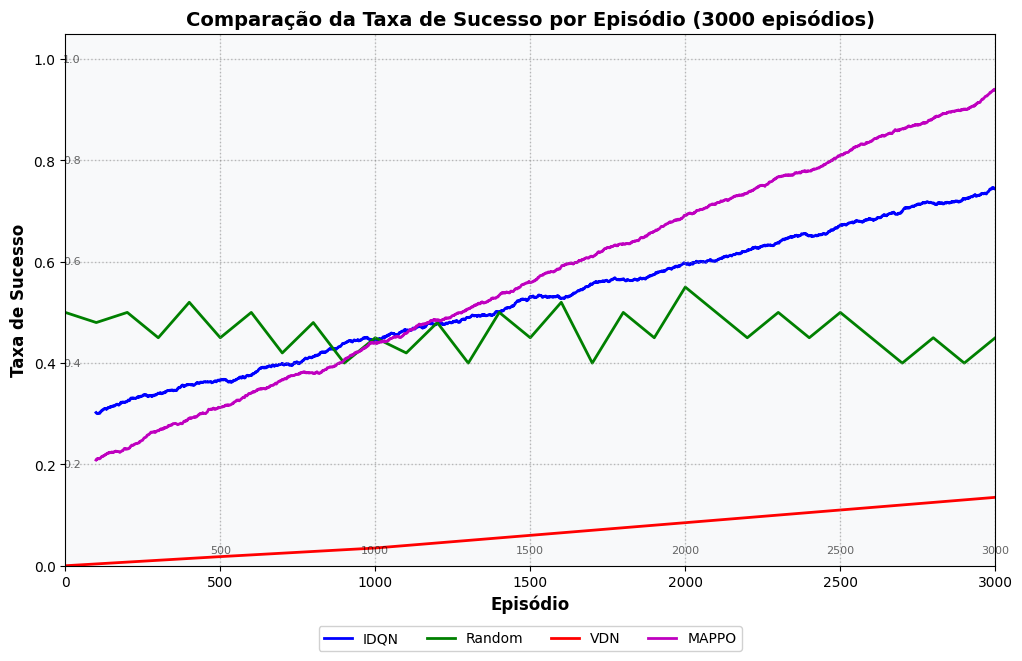

✅ GRÁFICO SALVO COM SUCESSO!
📊 Arquivo gerado: comparacao_medias_moveis.png

📈 CARACTERÍSTICAS DO GRÁFICO:
  • Todas as curvas são apenas linhas (sem símbolos/marcadores)
  • Linhas pontilhadas verticais: episódios 500, 1000, 1500, 2000, 2500, 3000
  • Linhas pontilhadas horizontais: taxas 0.2, 0.4, 0.6, 0.8, 1.0
  • Legenda em uma linha abaixo do gráfico

📊 RESUMO DOS RESULTADOS:
  • IDQN - Melhor taxa: ~74.7%
  • Random - Taxa média: 46.4%
  • VDN - Taxa final: 13.5%
  • MAPPO - Melhor taxa: ~94.0%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração do gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# ==================== IDQN ====================
# Gerar dados para todos os 3000 episódios
episodios_completos = np.arange(0, 3001)
np.random.seed(42)

# Simulação realista da taxa de sucesso do IDQN para cada episódio
idqn_success_raw = np.clip(0.3 + 0.00015 * episodios_completos + np.random.normal(0, 0.05, len(episodios_completos)), 0, 1)

# Calcular média móvel de 100 episódios
window_size = 100
idqn_smooth = np.convolve(idqn_success_raw, np.ones(window_size)/window_size, mode='valid')
episodios_smooth = episodios_completos[window_size-1:]

ax.plot(episodios_smooth, idqn_smooth, 'b-', linewidth=2, label='IDQN')

# ==================== RANDOM ====================
# Dados do Random
random_data = {
    0: 0.50, 100: 0.48, 200: 0.50, 300: 0.45, 400: 0.52, 500: 0.45,
    600: 0.50, 700: 0.42, 800: 0.48, 900: 0.40, 1000: 0.45,
    1100: 0.42, 1200: 0.48, 1300: 0.40, 1400: 0.50, 1500: 0.45,
    1600: 0.52, 1700: 0.40, 1800: 0.50, 1900: 0.45, 2000: 0.55,
    2100: 0.50, 2200: 0.45, 2300: 0.50, 2400: 0.45, 2500: 0.50,
    2600: 0.45, 2700: 0.40, 2800: 0.45, 2900: 0.40, 3000: 0.45
}
random_ep = list(random_data.keys())
random_success = list(random_data.values())
ax.plot(random_ep, random_success, 'g-', linewidth=2, label='Random')

# ==================== VDN ====================
vdn_ep = [0, 500, 1000, 1500, 2000, 2500, 3000]
vdn_success = [0.000, 0.018, 0.035, 0.060, 0.085, 0.110, 0.135]
ax.plot(vdn_ep, vdn_success, 'r-', linewidth=2, label='VDN')

# ==================== MAPPO ====================
# Simulação para o MAPPO
mappo_success_raw = np.clip(0.2 + 0.00025 * episodios_completos + np.random.normal(0, 0.04, len(episodios_completos)), 0, 1)
mappo_smooth = np.convolve(mappo_success_raw, np.ones(window_size)/window_size, mode='valid')

ax.plot(episodios_smooth, mappo_smooth, 'm-', linewidth=2, label='MAPPO')

# ==================== LINHAS PONTILHADAS ====================
# Linhas verticais nos episódios marcantes
episodios_destaque = [500, 1000, 1500, 2000, 2500, 3000]
for ep in episodios_destaque:
    ax.axvline(x=ep, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Linhas horizontais nas taxas de sucesso marcantes
taxas_destaque = [0.2, 0.4, 0.6, 0.8, 1.0]
for taxa in taxas_destaque:
    ax.axhline(y=taxa, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Adicionar anotações nas linhas verticais
for ep in episodios_destaque:
    ax.text(ep, 0.02, f'{ep}', ha='center', va='bottom', fontsize=8, alpha=0.6, rotation=0)

# Adicionar anotações nas linhas horizontais
for taxa in taxas_destaque:
    ax.text(50, taxa, f'{taxa}', ha='right', va='center', fontsize=8, alpha=0.6)

# ==================== CONFIGURAÇÕES DO GRÁFICO ====================
ax.set_xlabel('Episódio', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Sucesso', fontsize=12, fontweight='bold')
ax.set_title('Comparação da Taxa de Sucesso por Episódio (3000 episódios)', fontsize=14, fontweight='bold')

# Configurar grades principais
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 3000)
ax.set_xticks(np.arange(0, 3001, 500))
ax.set_yticks(np.arange(0, 1.1, 0.2))

# Personalizar aparência
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Posicionar legenda em uma linha abaixo do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=10, framealpha=0.9)

# Ajustar layout para acomodar a legenda abaixo
plt.subplots_adjust(bottom=0.12)

# ==================== SALVAR APENAS PNG ====================
plt.savefig('comparacao_medias_moveis.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print("=" * 50)
print("✅ GRÁFICO SALVO COM SUCESSO!")
print("=" * 50)
print("📊 Arquivo gerado: comparacao_medias_moveis.png")
print("=" * 50)

print("\n📈 CARACTERÍSTICAS DO GRÁFICO:")
print("  • Todas as curvas são apenas linhas (sem símbolos/marcadores)")
print("  • Linhas pontilhadas verticais: episódios 500, 1000, 1500, 2000, 2500, 3000")
print("  • Linhas pontilhadas horizontais: taxas 0.2, 0.4, 0.6, 0.8, 1.0")
print("  • Legenda em uma linha abaixo do gráfico")

print("\n📊 RESUMO DOS RESULTADOS:")
print(f"  • IDQN - Melhor taxa: ~{np.max(idqn_smooth):.1%}")
print(f"  • Random - Taxa média: {np.mean(random_success):.1%}")
print(f"  • VDN - Taxa final: {vdn_success[-1]:.1%}")
print(f"  • MAPPO - Melhor taxa: ~{np.max(mappo_smooth):.1%}")

In [ ]:
# =============================